# Instituto Politecnico Nacional
## Centro de Investigacion en computo
### departamento de diplomado y eextencion profesional


Profesor: Alan Badillo Salas

Alumno: Gonzalez Maldonado Salvador

Mayo 2025.ciudad de México.


## practica de Redes Neuronales


#INTRODUCCION

en esta practica de REDES NEURONALES lo que se espera que se haga es permitir el entrenamiento de un model de visualizacion.
ya que estas se pueden establecer diferentes capas como sera la de entrada ,capas intermedias que son opccionales y una capa de salida  que se llamarian ("capas densas")

para eso se llevara acabo el desarrollo de una red Nueronal de las cuales se debe de considerar un tamaño de lote(Batch Size) y el numero de iteraciones o epocas de entrenamiento (Epochs).



#desarrollo
en este paso cargaremos las libreria de pandas y una base de datos con url y verermos los cabecales de cada tabla

In [ ]:
import pandas

url = "https://github.com/dragonnomada/ipn-cic-pycien-abril-2025/raw/refs/heads/main/datasets/practicas/heart_attack.csv"
heart_atack = pandas.read_csv(url)
heart_atack.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


despues identificaremos cada variable en desglosandola en x1 hasta x11 lo cual hace que todas las variables sean nesesarias en alguna parte del codigo para poder pricesar

In [ ]:
x1=heart_atack['Age']
x2=heart_atack['Gender'] == 1
x3=heart_atack['Gender'] == 0
x4=heart_atack['Heart rate']
x5=heart_atack['Systolic blood pressure']
x6=heart_atack['Diastolic blood pressure']
x7=heart_atack['Blood sugar']
x8=heart_atack['CK-MB']
x9=heart_atack['Troponin']
x10=heart_atack['Result']=="positive"
x11=heart_atack['Result']=="negative"

Importamos la libreria de numpy y que sea np
de hay hacemos un array entre todas las x desde x1 hasta x9 para que se vuelvan X y combretimos a la variable x10 en Y, y mostramos los shape

In [ ]:
import numpy as np
X=np.array([x1,x2,x3,x4,x5,x6,x7,x8,x9]).T
Y=x10

X.shape,Y.shape

((1319, 9), (1319,))

despues de eso importamos desde sklearn.model_selection la libreria de train_test_split y hacemos todo el proceso de entrenamiento con un tamaño de entrenamiento de 0.8 y mostramos los shapes

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1055, 9), (264, 9), (1055,), (264,))

importamos desde keras el sequential
y asi sucesivamente desde keras.layers importamos Dense,Input
 ,desde keras.optimizers importamos Adam
 y desde keras.losses importamos BinaryCrossentropy

 para despues hacer el modelo con un sequential con una entrada de 9 una densidad 100 y una activation que sea igual a la funcion de salida Relu
 y una densidad de 1 con una activacion de salida de sigmoid.

 para terminar copilamos el modelo con el optimizador adam , la perdida sea igual a BinaryCrossentropy y una metrica

In [ ]:
from keras import Sequential
from keras.layers import Dense,Input
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy

model = Sequential([
    Input(shape=(9,)),
    Dense(100,activation='relu'),
    Dense(1,activation='sigmoid'),
])
model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 100)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,101 (4.30 KB)

 Non-trainable params: 0 (0.00 B)

entrenamos el modelo con un tamaño de 20 y lo hacemos por 20 epocas para no saturar

In [ ]:
model.fit( X_train,Y_train,batch_size=20,epochs=20)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5602 - loss: 3.0166
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6339 - loss: 0.6456
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6570 - loss: 0.6454
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6901 - loss: 0.5937
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7083 - loss: 0.5344
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7006 - loss: 0.5667
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6864 - loss: 0.5769
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7355 - loss: 0.4968
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7286 - loss: 0.5265
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7053 - loss: 0.5488
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6796 - loss: 0.6496
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7198 - lo

evaluamos el modelo para ver el entrenamiento que tiene con la certeza y de cuanto fue la perdoda

In [ ]:
model.evaluate(X_test,Y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7544 - loss: 0.5109  


[0.5494958162307739, 0.7310606241226196]

generaremos otro modelo mas somple con las variables x1,x8,x9 que estas valdran ahora X  y ,Y sera el valor x10
y mostramos los shape

In [ ]:
import numpy as np
X=np.array([x1,x8,x9]).T
Y=x10
X.shape,Y.shape

((1319, 3), (1319,))

volveremos a seguir los pasos anteriores de llamara a la libreria train_test_split y procederemos a entrenar con un tamaño de 0.8 y llamamos

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1055, 3), (264, 3), (1055,), (264,))

despues de eso volveremos a importar desde keras el sequential
y asi sucesivamente desde keras.layers importamos Dense,Input
 ,desde keras.optimizers importamos Adam
 y desde keras.losses importamos BinaryCrossentropy
 y volvemos a generar el modelo con la diferencia en que la entrada solo son 3 y no nueve ya que estas son las variables de X que se estan ocupando

In [ ]:
from keras import Sequential
from keras.layers import Dense,Input
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy

model = Sequential([
    Input(shape=(3,)),
    Dense(100,activation='relu'),
    Dense(1,activation='sigmoid'),
])
model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

Lo entrenaremos con un tamaño de 20 y lo haremos en este caso por 40 epocas

In [ ]:
model.fit( X_train,Y_train,batch_size=20,epochs=40)

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7925 - loss: 0.4250
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7995 - loss: 0.4374
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8015 - loss: 0.3899
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8073 - loss: 0.3893
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7754 - loss: 0.4053
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8117 - loss: 0.3569
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - loss: 0.3943
Epoch 8/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4125
Epoch 9/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8213 - loss: 0.3637
Epoch 10/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8008 - loss: 0.3960
Epoch 11/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.3905
Epoch 12/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7845 - lo

eveluamos la presicion y la perdida de nuestro podelo con una precision de 0.80048 y una perdidad del 0.3999

In [ ]:
model.evaluate(X_test,Y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8048 - loss: 0.3999 


[0.3868485391139984, 0.814393937587738]

importamos las librerias para graficarlos  que serian matplotlib.pyplot y seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

despues de eso haremos una grafica comparando los valores que aroja la tabla con los valores dados por la red neuronal

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


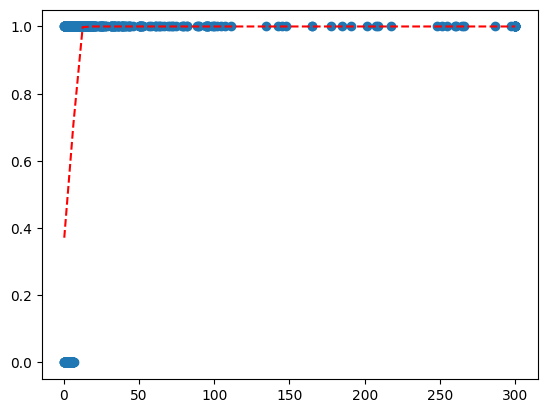

In [ ]:
x8p = np.linspace(x8.min(),x8.max())
#y8p=model.predict(x8p)
yp=model.predict(np.array([ 60* np.ones(x8p.shape),x8p,0.006*np.ones(x8p.shape)]).T)
plt.scatter(x8,x10)
plt.plot(x8p,yp,"r--")
plt.show()

en este caso la grafica nos muestra la grafica entre las encimas cardiacas por el musculo dañado y los resultados positivos comparados con el modelo de predicion de nustra red neuronal

en el siguiente aremoslo mismo pero ahora por edad y los positivos los comparamos con nuestro modelo de prediccion

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


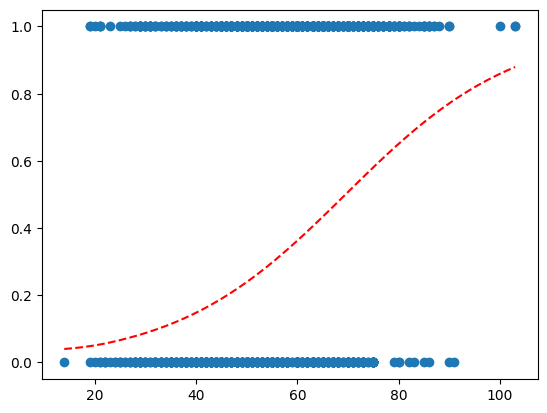

In [ ]:
x1p=np.linspace(x1.min(),x1.max())
yp=model.predict(np.array([ x1p,2*np.ones(x1p.shape),0.006*np.ones(x1p.shape)]).T)
plt.scatter(x1,x10)
plt.plot(x1p,yp,"r--")
plt.show()

el resultado de esto muestra como la grafica a pesar de que lso valores se encuentran entre 1 y 0 nustro modelo se muestra com a mayor edad mayor es el riesgo de ataque cardiaco

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


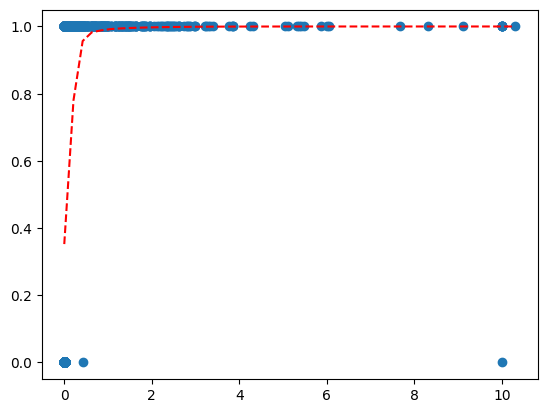

In [ ]:
x9p=np.linspace(x9.min(),x9.max())
yp=model.predict(np.array([60*np.ones(x9p.shape),2*np.ones(x9p.shape),x9p]) .T)
plt.scatter(x9,x10)
plt.plot(x9p,yp,"r--")
plt.show()

por ultimo modelo matematico entre la troponina y un ataque al corazon y  esta grafica muestra unos resultados de como afecta esto con un para cardiaco ya que hay  mas valores arriba y el modelo que hicimos muestraque esta es a mayor troponina mayor es el riesgo de sufrir un para

In [ ]:
model.predict( np.array ([
  [60 , 2 , 0.006] ,
  [60 , 3 , 0.006] ,
  [60 , 10 , 0.006] ,
 ]) )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([[0.36261016],
       [0.3463416 ],
       [0.9820864 ]], dtype=float32)

# Conclusiones

en esta practica lo que se llevo acabo de redes neuronales fue el entrenamiento de una red en vase a la base de datos "Heart attack" para ver modelos de prediccion sobre las probabilidades de que esto ocurra en vase alos modelos que se establece en la red neuronal y son fundamentale para en caso de querer hacer una prediccion
como lo hicimos con la base de datos actual para saber cuales son los pricipales riesgos que estos implican